<a href="https://colab.research.google.com/github/aahan-rd/ECON3916-Statistical-Machine-Learnin/blob/main/Class_12_OLS%2C_Hedonic_Pricing%2C_and_RMSE_Evaluation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.tools.eval_measures import rmse
import matplotlib.pyplot as plt

df = pd.read_csv("Zillow_ZHVI_2026_Micro.csv")
df

,Home_Value,Square_Footage,Property_Age,Distance_to_Transit,School_District_Rating
0,329705.74,1941.0,5.5,6.45,Excellent
1,183343.63,1364.3,35.2,2.15,Average
2,354551.73,2386.9,52.4,0.75,Good
3,325773.17,2192.1,50.2,5.25,Excellent
4,359743.12,3069.8,66.5,12.69,Excellent
...,...,...,...,...,...
995,389368.45,2744.4,4.1,10.49,Excellent
996,380314.99,2512.3,8.7,6.18,Average
997,230005.36,1765.8,73.6,6.57,Average
998,360943.75,2021.1,16.6,5.48,Poor


In [ ]:
formula = 'Home_Value ~ Square_Footage + Property_Age + Distance_to_Transit'
print("Patsy formula defined: ", formula)

Patsy formula defined:  Home_Value ~ Square_Footage + Property_Age + Distance_to_Transit


In [ ]:
model = smf.ols(formula, data=df)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             Home_Value   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     1087.
Date:                Mon, 16 Mar 2026   Prob (F-statistic):          1.73e-313
Time:                        19:41:48   Log-Likelihood:                -12072.
No. Observations:                1000   AIC:                         2.415e+04
Df Residuals:                     996   BIC:                         2.417e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            8.898e+04   6

In [ ]:
predictions = results.predict(df)
print("Predictions generated successfully.")
print(predictions.head())

Predictions generated successfully.
0    312391.414318
1    222863.862825
2    333724.313631
3    307478.039316
4    392700.239719
dtype: float64


In [ ]:
model_rmse = rmse(df['Home_Value'], predictions)
print(f"\nThe Predictive RMSE is: ${model_rmse:,.2f}")


The Predictive RMSE is: $42,341.60


In [ ]:
fitted_values = results.fittedvalues
residuals = results.resid
std_residuals = residuals.std()
outliers = (residuals > 2 * std_residuals) | (residuals < -2 * std_residuals)

print("Fitted Values (head):\n", fitted_values.head())
print("\nResiduals (head):\n", residuals.head())
print(f"\nStandard Deviation of Residuals: {std_residuals:.2f}")
print("\nOutliers (head):\n", outliers.head())

Fitted Values (head):
 0    312391.414318
1    222863.862825
2    333724.313631
3    307478.039316
4    392700.239719
dtype: float64

Residuals (head):
 0    17314.325682
1   -39520.232825
2    20827.416369
3    18295.130684
4   -32957.119719
dtype: float64

Standard Deviation of Residuals: 42362.79

Outliers (head):
 0    False
1    False
2    False
3    False
4    False
dtype: bool


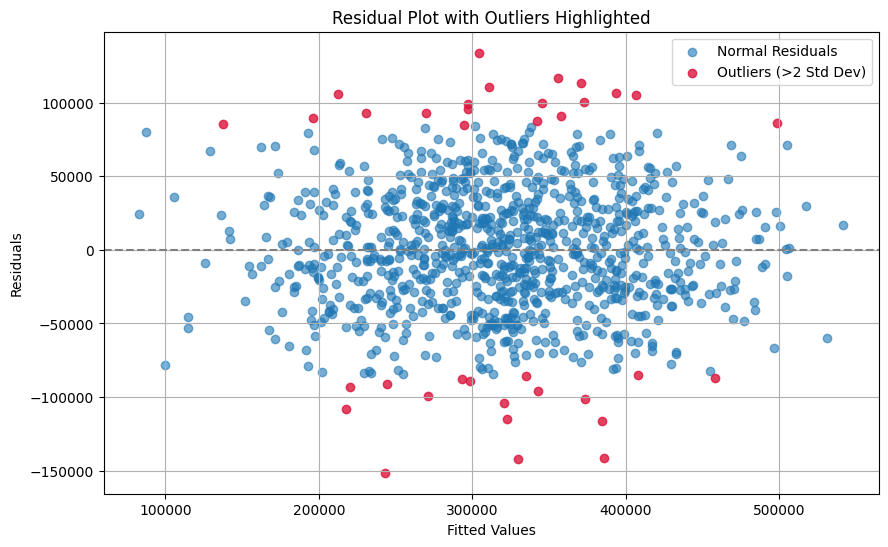

Residual plot generated. An interactive plot can be created with libraries like Plotly or Bokeh if true interactivity beyond matplotlib's basic zoom/pan is required. For this task, matplotlib's built-in interactivity is assumed.


In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(fitted_values[~outliers], residuals[~outliers], alpha=0.6, label='Normal Residuals')
plt.scatter(fitted_values[outliers], residuals[outliers], color='crimson', alpha=0.8, label='Outliers (>2 Std Dev)')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot with Outliers Highlighted')
plt.legend()
plt.grid(True)
plt.show()

print("Residual plot generated. An interactive plot can be created with libraries like Plotly or Bokeh if true interactivity beyond matplotlib's basic zoom/pan is required. For this task, matplotlib's built-in interactivity is assumed.")

In [ ]:
import plotly.express as px
import pandas as pd

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'fitted_values': fitted_values,
    'residuals': residuals,
    'is_outlier': outliers
})

# Define colors for the plot
color_map = {False: 'blue', True: 'crimson'}

# Create the interactive scatter plot
fig = px.scatter(plot_data,
                 x='fitted_values',
                 y='residuals',
                 color='is_outlier',
                 color_discrete_map=color_map,
                 title='Interactive Residual Plot with Outliers Highlighted',
                 labels={'fitted_values': 'Fitted Values', 'residuals': 'Residuals', 'is_outlier': 'Outlier'})

# Add a horizontal line at y=0
fig.add_hline(y=0, line_dash="dash", line_color="gray")

# Update layout for better readability (optional, but good practice)
fig.update_layout(
    xaxis_title='Fitted Values',
    yaxis_title='Residuals',
    legend_title='Is Outlier',
    hovermode='closest'
)

# Display the plot
fig.show()

print("Interactive residual plot generated successfully.")

Interactive residual plot generated successfully.
